# Soccermatics Pro: Tactical Analysis of Rodri (Euro 2024)

*Author:* Hannah Nyarkoa Oduro  
*Date:* December 2025  
*Module:* Event Data & Visualisation  
*Data Source:* StatsBomb Open Data (Euro 2024)

## Project Overview
This notebook analyses the performance of *Rodri (Spain)* during the Euro 2024 tournament. 
The analysis focuses on two key performance indicators:
1. *Defensive Contribution:* High-pressing ball recoveries.
2. *Ball Progression:* Progressive passing compared to other tournament midfielders.

## Analytical Goals
Using StatsBomb event data, this project aims to:
1.  *Quantify Control:* Compare Rodri's passing volume and completion rate against England's double pivot (Rice & Mainoo).
2.  *Visualize Impact:* Map Rodri's progressive passes and defensive recoveries to show how he dominated the central channel.
3.  *Contextualize Efficiency:* Use per-90 metrics to demonstrate how Spain's "Engine Room" functioned before his substitution.


In [17]:
from statsbombpy import sb

In [19]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
# available competitions
sb.competitions()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
70,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2024-02-12T14:45:05.702250,2021-06-13T16:17:31.694,None,2024-02-12T14:45:05.702250
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263
73,72,107,International,Women's World Cup,female,False,True,2023,2025-07-14T10:07:06.620906,2025-07-14T10:10:27.224586,2025-07-14T10:10:27.224586,2025-07-14T10:07:06.620906


In [25]:
# 1. GET THE DATA (Euro 2024)
# Fetch all matches for Euro 2024 (Competition 55, Season 282)
matches = sb.matches(competition_id=55, season_id=282)

In [27]:
from mplsoccer import Sbopen
import pandas as pd
parser = Sbopen()

In [29]:
# Find the Spain vs England match
match_se = matches[
    (matches['home_team'] == 'Spain') & 
    (matches['away_team'] == 'England')
]

match_id_se = match_se.match_id.values[0]
match_id_se

3943043

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
match_id_se = match_se.match_id.values[0]
print("Match ID =", match_id_se)

# Load events
events = parser.event(match_id_se)[0]
print("Events loaded:", events.shape)

Match ID = 3943043
Events loaded: (3312, 75)


In [35]:
# 3. Load all events from the match
# parser.event returns a tuple; the first element [0] is the event dataframe
events = parser.event(match_id_se)[0]
print("Events loaded:", events.shape)

Events loaded: (3312, 75)


In [37]:
# 4. Check how Rodri's name appears in the dataset
print(events['player_name'].unique())

[nan 'Kobbie Mainoo' 'Jordan Pickford' 'Bukayo Saka' 'Unai Simón Mendibil'
 'Robin Aime Robert Le Normand' 'Daniel Carvajal Ramos' 'Jude Bellingham'
 'Declan Rice' 'Daniel Olmo Carvajal' 'Álvaro Borja Morata Martín'
 'Lamine Yamal Nasraoui Ebana' 'Marc Guehi' 'Phil Foden'
 'Rodrigo Hernández Cascante' 'Aymeric Laporte' 'Kyle Walker' 'Luke Shaw'
 'Harry Kane' 'John Stones' 'Nicholas Williams Arthuer'
 'Marc Cucurella Saseta' 'Fabián Ruiz Peña' 'Martín Zubimendi Ibáñez'
 'Ollie Watkins' 'Mikel Oyarzabal Ugarte' 'Cole Palmer'
 'José Ignacio Fernández Iglesias' 'Ivan Toney' 'Mikel Merino Zazón']


In [39]:
# 5. Filter events to only keep Rodri
rodri_events = events[events['player_name'] == 'Rodrigo Hernández Cascante']
print("Rodri events:", rodri_events.shape)
rodri_events.head()

Rodri events: (105, 75)


,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,block_offensive,shot_deflected,block_deflection,foul_committed_offensive,injury_stoppage_in_chain,substitution_replacement_id,substitution_replacement_name,pass_goal_assist,pass_cut_back,block_save_block
42,84f77995-f421-46d1-943b-3a5121f5e89e,43,1,00:01:02.789000,1,2,4,NaN,3943043,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,aa5057eb-7f83-4860-85e3-ef4a02b0ad6a,44,1,00:01:02.789000,1,2,4,2.915230,3943043,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45,ed68e1be-c311-44ec-b705-508da045fced,46,1,00:01:05.704000,1,5,4,1.549079,3943043,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,5be314b3-17b9-4303-97d9-4a6c8d9ae5ba,160,1,00:03:32.345000,3,32,9,NaN,3943043,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
160,4988b03e-856f-471a-8acc-918061c0704a,161,1,00:03:32.345000,3,32,9,0.588092,3943043,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# 6. Filter actions by team (Spain)
spain_events = events[events['team_name'] == 'Spain']
print("Spain events:", spain_events.shape)

Spain events: (2016, 75)


In [43]:
# 7. Example: Filter Rodri's successful passes
rodri_passes = rodri_events[
    (rodri_events['type_name'] == 'Pass') &
    (rodri_events['outcome_name'].isnull())  # Successful pass = outcome is NaN
]

In [45]:
print("Rodri successful passes:", rodri_passes.shape)

Rodri successful passes: (29, 75)


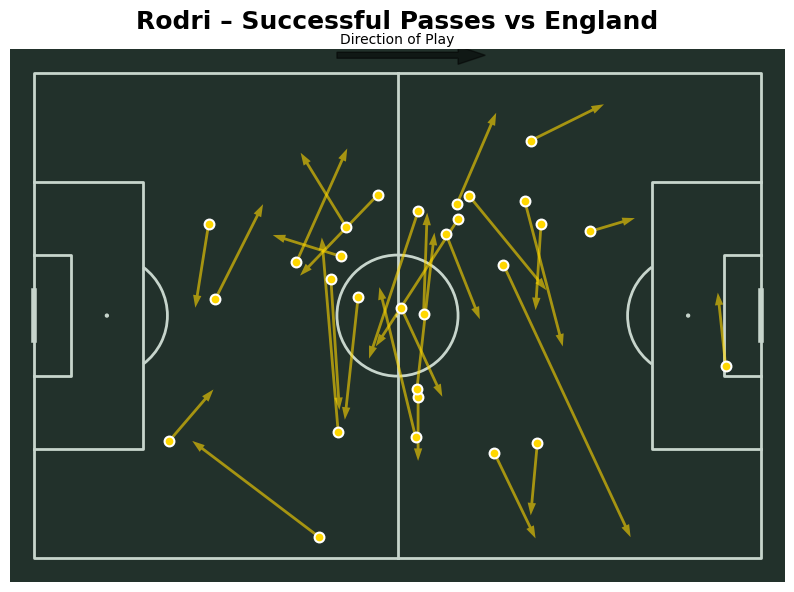

In [73]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
# Setup the figure
fig, ax = plt.subplots(figsize=(10, 7))
fig.set_facecolor('#FFFFFF') # Dark background for the whole figure

# 1. Draw pitch 
pitch = Pitch(
    pitch_type='statsbomb', 
    pitch_color='#22312b', 
    line_color='#c7d5cc',
    line_zorder=2
)
pitch.draw(ax=ax)

# 2. An arrow showing direction of play 
# Assuming Left -> Right
ax.arrow(x=50, y=-3, dx=20, dy=0, width=1, color='#000000', alpha=0.5)
ax.text(60, -5, "Direction of Play", color='#000000', ha='center', fontsize=10)

# 3. Plot the Passes
pitch.arrows(rodri_passes['x'], rodri_passes['y'],
             rodri_passes['end_x'], rodri_passes['end_y'],
             width=2, headwidth=3, headlength=4.5, 
             color='#ffd700', alpha=0.6, lw=1.5, zorder=3, ax=ax)

pitch.scatter(rodri_passes['x'], rodri_passes['y'],
              s=50, color='#ffd700', edgecolors='#FFFFFF', zorder=4, linewidth=1.5, ax=ax)

# 4. Title and labels
ax.set_title(f"Rodri – Successful Passes vs England", 
             fontsize=18, color='black', fontweight='bold', pad=15)


plt.savefig("rodri_pass_map_improved.png", dpi=300, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

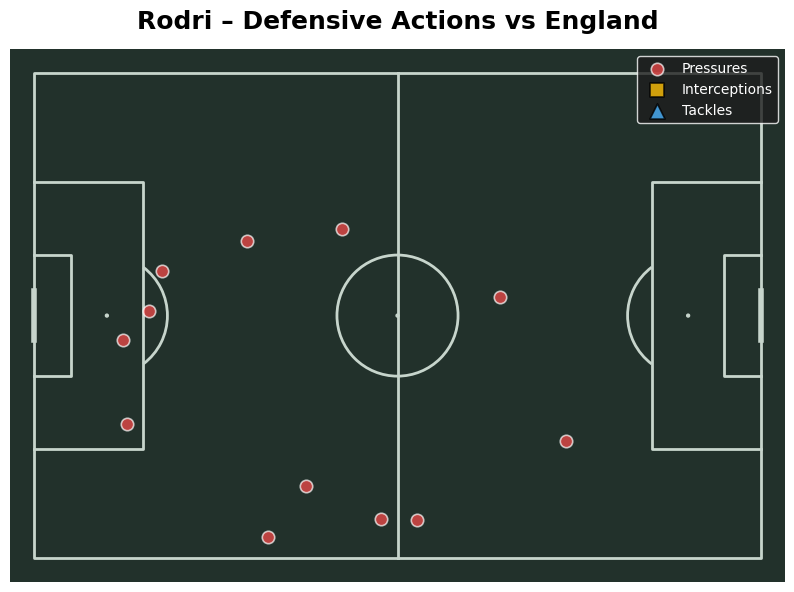

In [75]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# Filter Rodri's defensive actions
rodri_def = rodri_events[
    rodri_events['type_name'].isin(['Pressure', 'Tackle', 'Interception'])
]

# Setup figure
fig, ax = plt.subplots(figsize=(10, 7))
fig.set_facecolor('#FFFFFF')

# Create pitch
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#22312b',
    line_color='#c7d5cc'
)
pitch.draw(ax=ax)

# Plot each type of defensive action with a different marker
pitch.scatter(
    rodri_def.loc[rodri_def['type_name']=='Pressure', 'x'],
    rodri_def.loc[rodri_def['type_name']=='Pressure', 'y'],
    s=80, color='#ff4b4b', edgecolors='white', linewidth=1.2, alpha=0.7, ax=ax,
    label='Pressures'
)

pitch.scatter(
    rodri_def.loc[rodri_def['type_name']=='Interception', 'x'],
    rodri_def.loc[rodri_def['type_name']=='Interception', 'y'],
    s=100, marker='s', color='#ffc107', edgecolors='black', linewidth=1.2, alpha=0.8, ax=ax,
    label='Interceptions'
)
pitch.scatter(
    rodri_def.loc[rodri_def['type_name']=='Tackle', 'x'],
    rodri_def.loc[rodri_def['type_name']=='Tackle', 'y'],
    s=120, marker='^', color='#4bb3fd', edgecolors='black', linewidth=1.2, alpha=0.8, ax=ax,
    label='Tackles'
)

# Title
ax.set_title(
    "Rodri – Defensive Actions vs England",
    fontsize=18, color='black', fontweight='bold', pad=15
)

# Legend
legend = ax.legend(facecolor='#1e1e1e', edgecolor='white', fontsize=10)
for text in legend.get_texts():
    text.set_color('white')

# Save
plt.savefig("rodri_defensive_actions.png", dpi=300, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

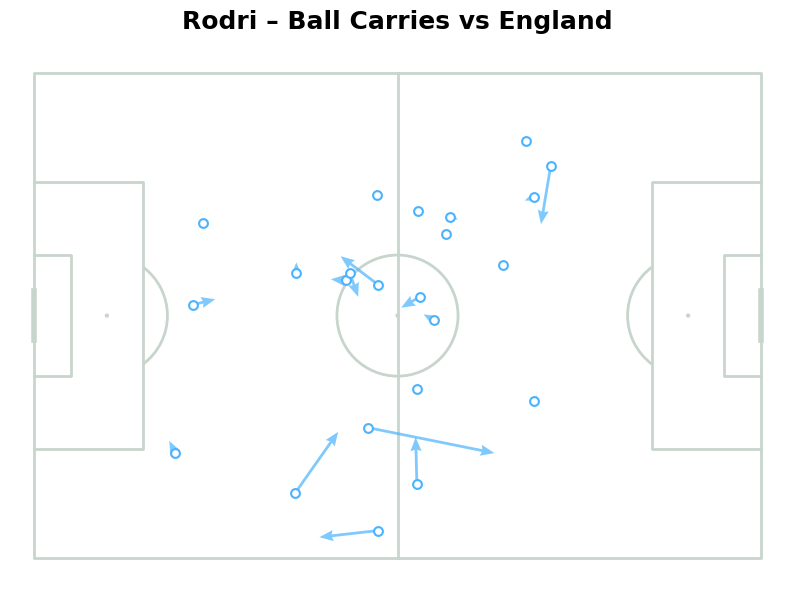

In [67]:
# Filter Rodri's carries
rodri_carries = rodri_events[rodri_events['type_name'] == 'Carry']

# Setup figure
fig, ax = plt.subplots(figsize=(10, 7))
fig.set_facecolor('#FFFFFF')

pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#FFFFFF',
    line_color='#c7d5cc'
)
pitch.draw(ax=ax)

# Plot arrows for carries
pitch.arrows(
    rodri_carries['x'], rodri_carries['y'],
    rodri_carries['end_x'], rodri_carries['end_y'],
    width=2, headwidth=4, headlength=5,
    color='#4bb3fd', alpha=0.7, ax=ax
)

pitch.scatter(
    rodri_carries['x'], rodri_carries['y'],
    s=40, color='#FFFFFF', edgecolors='#4bb3fd', linewidth=1.5, ax=ax
)

# Title
ax.set_title(
    "Rodri – Ball Carries vs England",
    fontsize=18, color='black', fontweight='bold', pad=15
)

# Save
plt.savefig("rodri_carries_map.png", dpi=300, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()


In [53]:
events[events['type_name'] == "Carry"].columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'body_part_id', 'body_part_name',
       'sub_type_id', 'sub_type_name', 'x', 'y', 'outcome_id', 'outcome_name',
       'under_pressure', 'out', 'counterpress', 'pass_switch',
       'dribble_nutmeg', 'aerial_won', 'pass_cross', 'technique_id',
       'technique_name', 'pass_no_touch', 'foul_won_defensive', 'off_camera',
       'pass_assisted_shot_id', 'pass_shot_assist', 'shot_one_on_one',
       'shot_statsbomb_xg', 'shot_key_pass_id', 'goalkeeper_position_id',
       'goalkeeper_position_name', 'end_z',

In [55]:
midfielder_names = [
    # Spain
    "Rodrigo Hernández Cascante",
    "Fabián Ruiz Peña",
    "Daniel Olmo Carvajal",
    "Martín Zubimendi Ibáñez",
    "Mikel Merino Zazón",
    
    # England
    "Declan Rice",
    "Jude Bellingham",
    "Kobbie Mainoo",
    "Phil Foden"
]

In [57]:
midfielders = events[events['player_name'].isin(midfielder_names)]
print("Midfielder rows:", midfielders.shape)

Midfielder rows: (1096, 75)


In [59]:
rodri_name = "Rodrigo Hernández Cascante"

rodri_events = events[events['player_name'] == rodri_name]
print("Rodri rows:", rodri_events.shape)

Rodri rows: (105, 75)


In [61]:
import pandas as pd

player_stats = []

for player in midfielder_names:
    df = events[events['player_name'] == player]
    
    passes = df[df['type_name'] == 'Pass']
    successful_passes = passes[passes['outcome_name'].isnull()]
    final_3rd_passes = passes[passes['end_x'] > 66]  # Final third threshold
    
    pressures = df[df['type_name'] == 'Pressure']
    tackles = df[df['type_name'] == 'Tackle']
    interceptions = df[df['type_name'] == 'Interception']
    
    player_stats.append({
        'player_name': player,
        'passes_attempted': len(passes),
        'passes_completed': len(successful_passes),
        'final_third_passes': len(final_3rd_passes),
        'pressures': len(pressures),
        'tackles': len(tackles),
        'interceptions': len(interceptions)
    })

stats_df = pd.DataFrame(player_stats)
stats_df

,player_name,passes_attempted,passes_completed,final_third_passes,pressures,tackles,interceptions
0,Rodrigo Hernández Cascante,32,29,14,12,0,0
1,Fabián Ruiz Peña,64,56,36,18,0,0
2,Daniel Olmo Carvajal,32,25,23,26,0,1
3,Martín Zubimendi Ibáñez,26,23,10,7,0,0
4,Mikel Merino Zazón,0,0,0,1,0,0
5,Declan Rice,42,32,17,13,0,1
6,Jude Bellingham,35,25,21,27,0,1
7,Kobbie Mainoo,18,14,7,16,0,1
8,Phil Foden,20,16,8,28,0,0


In [63]:
rodri_stats = stats_df[stats_df['player_name'] == rodri_name]
rodri_stats


,player_name,passes_attempted,passes_completed,final_third_passes,pressures,tackles,interceptions
0,Rodrigo Hernández Cascante,32,29,14,12,0,0


In [65]:
def compute_z_score(column):
    mean = stats_df[column].mean()
    std = stats_df[column].std()
    rodri_value = float(rodri_stats[column])
    return (rodri_value - mean) / std

rodri_z = {
    'passes_completed_z': compute_z_score('passes_completed'),
    'final_third_passes_z': compute_z_score('final_third_passes'), 
    'pressures_z': compute_z_score('pressures'),
    'tackles_z': compute_z_score('tackles'),
    'interceptions_z': compute_z_score('interceptions')
}

rodri_z

{'passes_completed_z': 0.29923021867269983,
 'final_third_passes_z': -0.10424304453346032,
 'pressures_z': -0.47573558946714245,
 'tackles_z': nan,
 'interceptions_z': -0.8432740427115677}